In [1]:
import os
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scvi
from sklearn.metrics import classification_report
from scarches.models.scpoli import scPoli
from scarches.dataset.trvae.data_handling import remove_sparsity

import warnings
warnings.filterwarnings('ignore')

# 设置参数
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(dpi=100)
sc.set_figure_params(figsize=(4, 4))
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (4, 4)
sc.settings.seed = 42

/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/torch/cuda/__init__.py:56: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/home/liuxiaodongLab/jiangjing/miniconda3/envs/agent_new/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel fro

In [2]:
# 加载您的combined数据
print("加载combined数据...")
adata = sc.read_h5ad("/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251021_fetal_adult_brain_merge_rename_scdevelopment/output/combined_sampled_optimized_counts.h5ad")
print(f"数据维度: {adata.n_obs} 细胞, {adata.n_vars} 基因")

加载combined数据...
数据维度: 499978 细胞, 27565 基因


In [5]:
print(adata.obs['orig.ident'])

10X357_2:GCCCAGAGTGACCGTC    Kimberly Siletti
10X222_8:TTCACGCTCCGTGTAA    Kimberly Siletti
10X221_5:GGTGTTACACGCGCTA    Kimberly Siletti
10X319_1:CTGAGCGAGTATAGAC    Kimberly Siletti
10X241_3:TTAGGGTTCCACGTCT    Kimberly Siletti
                                   ...       
SRX300884_SRX300884                  Xue_2013
SRX300876_SRX300876                  Xue_2013
SRX300882_SRX300882                  Xue_2013
SRX300886_SRX300886                  Xue_2013
SRX300877_SRX300877                  Xue_2013
Name: orig.ident, Length: 499978, dtype: category
Categories (13, object): ['Ai', 'Braun', 'Kimberly Siletti', 'Petropoulos_2016', ..., 'tyser', 'xiang', 'zeng', 'zhou']


In [3]:
# use 2000hvg
sc.settings.seed = 42
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["logcounts"] = adata.X.copy()

sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="cell_ranger", batch_key="orig.ident")

# Reorganize combined_adata with highly variable genes (HVGs)
adata_hvg = adata[:, adata.var.highly_variable].copy()
combined_adata = adata_hvg

In [4]:
# === scPoli 整合 ===
print("\n=== scPoli 整合 ===")

enhanced_model_dir = './pre_adult_reference_model_lineage_v1/'
# 设置scPoli参数
condition_key = "orig.ident"  # 批次/条件信息
cell_type_key = "lineage"  # 细胞类型信息

print(f"条件变量: {condition_key}")
print(f"细胞类型变量: {cell_type_key}")
print(f"条件分布: {combined_adata.obs[condition_key].value_counts()}")
print(f"细胞类型分布: {combined_adata.obs[cell_type_key].value_counts()}")

# 早期停止参数
early_stopping_kwargs = {
    "early_stopping_metric": "val_prototype_loss",
    "mode": "min", 
    "threshold": 0,
    "patience": 20,
    "reduce_lr": True,
    "lr_patience": 13,
    "lr_factor": 0.1,
}

# 训练scPoli模型
print("训练scPoli模型...")

scpoli_model = scPoli(
    adata=combined_adata,
    condition_keys=condition_key,
    cell_type_keys=cell_type_key, 
    embedding_dims=5,
    recon_loss='nb',
)

scpoli_model.train(
    n_epochs=50,
    pretraining_epochs=40,
    early_stopping_kwargs=early_stopping_kwargs,
    eta=5,
)

# Fix numeric columns stored as strings
numeric_cols = ['nCount_RNA', 'nFeature_RNA', 'percent.mt']
for col in numeric_cols:
    if col in combined_adata.obs.columns:
        combined_adata.obs[col] = pd.to_numeric(combined_adata.obs[col], errors='coerce')

# Fix remaining object columns
for col in combined_adata.obs.columns:
    if combined_adata.obs[col].dtype == 'object':
        # Try category first (ideal for AnnData)
        if combined_adata.obs[col].nunique() / len(combined_adata) < 0.5:  # heuristic
            combined_adata.obs[col] = combined_adata.obs[col].astype('category')
        else:
            combined_adata.obs[col] = combined_adata.obs[col].astype('string')

# Now save
try:
    print("Saving the enhanced model...")
    scpoli_model.save(enhanced_model_dir, overwrite=True, save_anndata=True)
    print(f"✅ Enhanced model saved to {enhanced_model_dir}")
except Exception as e:
    print(f"❌ Error: {e}")





INFO:scarches.trainers.scpoli.trainer:GPU available: False



=== scPoli 整合 ===
条件变量: orig.ident
细胞类型变量: lineage
条件分布: orig.ident
Kimberly Siletti    311416
Braun               153385
zeng                 13774
Ai                    8675
mole                  5229
zhou                  4244
tyser                 1189
Petropoulos_2016      1064
xiang                  521
Yanagida_2021          202
Yuan_2025              162
Yan_2013                89
Xue_2013                28
Name: count, dtype: int64
细胞类型分布: lineage
neural_ecto         369220
epi                  60558
meso_Exe.meso        21533
TE_TrB               17673
hemogenic            13359
Prelineage            6068
Amniotic_ecto         4973
NMP                   4296
Notochord             1005
ExE_endo               755
Primitive.streak       173
Endoderm               145
Inner Cell Mass         89
8C                      77
PGC                     35
Morula                  19
Name: count, dtype: int64
训练scPoli模型...
Embedding dictionary:
 	Num conditions: [13]
 	Embedding dim: [5]


In [5]:
# === scPoli 整合 ===
print("\n=== scPoli 整合 ===")

enhanced_model_dir = './pre_adult_reference_model_reanno_v1/'
# 设置scPoli参数
condition_key = "orig.ident"  # 批次/条件信息
cell_type_key = "reanno"  # 细胞类型信息

print(f"条件变量: {condition_key}")
print(f"细胞类型变量: {cell_type_key}")
print(f"条件分布: {combined_adata.obs[condition_key].value_counts()}")
print(f"细胞类型分布: {combined_adata.obs[cell_type_key].value_counts()}")

# 早期停止参数
early_stopping_kwargs = {
    "early_stopping_metric": "val_prototype_loss",
    "mode": "min", 
    "threshold": 0,
    "patience": 20,
    "reduce_lr": True,
    "lr_patience": 13,
    "lr_factor": 0.1,
}

# 训练scPoli模型
print("训练scPoli模型...")

scpoli_model = scPoli(
    adata=combined_adata,
    condition_keys=condition_key,
    cell_type_keys=cell_type_key, 
    embedding_dims=5,
    recon_loss='nb',
)

scpoli_model.train(
    n_epochs=50,
    pretraining_epochs=40,
    early_stopping_kwargs=early_stopping_kwargs,
    eta=5,
)

# Fix numeric columns stored as strings
numeric_cols = ['nCount_RNA', 'nFeature_RNA', 'percent.mt']
for col in numeric_cols:
    if col in combined_adata.obs.columns:
        combined_adata.obs[col] = pd.to_numeric(combined_adata.obs[col], errors='coerce')

# Fix remaining object columns
for col in combined_adata.obs.columns:
    if combined_adata.obs[col].dtype == 'object':
        # Try category first (ideal for AnnData)
        if combined_adata.obs[col].nunique() / len(combined_adata) < 0.5:  # heuristic
            combined_adata.obs[col] = combined_adata.obs[col].astype('category')
        else:
            combined_adata.obs[col] = combined_adata.obs[col].astype('string')

# Now save
try:
    print("Saving the enhanced model...")
    scpoli_model.save(enhanced_model_dir, overwrite=True, save_anndata=True)
    print(f"✅ Enhanced model saved to {enhanced_model_dir}")
except Exception as e:
    print(f"❌ Error: {e}")






=== scPoli 整合 ===
条件变量: orig.ident
细胞类型变量: reanno
条件分布: orig.ident
Kimberly Siletti    311416
Braun               153385
zeng                 13774
Ai                    8675
mole                  5229
zhou                  4244
tyser                 1189
Petropoulos_2016      1064
xiang                  521
Yanagida_2021          202
Yuan_2025              162
Yan_2013                89
Xue_2013                28
Name: count, dtype: int64
细胞类型分布: reanno
Neuron                            51723
Radial glia                       47870
Oligodendrocyte                   45315
Upper-layer intratelencephalic    42058
Splatter                          26975
                                  ...  
PGC                                  10
2C                                    9
Oocyte                                6
Zygote                                5
Pronucleus                            3
Name: count, Length: 99, dtype: int64
训练scPoli模型...


INFO:scarches.trainers.scpoli.trainer:GPU available: False


Embedding dictionary:
 	Num conditions: [13]
 	Embedding dim: [5]
Encoder Architecture:
	Input Layer in, out and cond: 2000 45 5
	Mean/Var Layer in/out: 45 10
Decoder Architecture:
	First Layer in, out and cond:  10 45 5
	Output Layer in/out:  45 2000 

Initializing dataloaders
Starting training
 |████████████████████| 100.0%  - val_loss:  748.04 - val_cvae_loss:  725.78 - val_prototype_loss:   22.26 - val_labeled_loss:    4.45
Saving the enhanced model...
✅ Enhanced model saved to ./pre_adult_reference_model_reanno_v1/


In [20]:
# 获取scPoli潜在表示
print("获取scPoli潜在表示...")
scpoli_model.model.eval()
if hasattr(combined_adata.X, 'toarray'):
    combined_adata.X = combined_adata.X.toarray()
data_latent_source  = scpoli_model.get_latent(combined_adata,mean=True)
combined_adata.obsm["scPoli"] = data_latent_source
# 基于scPoli的聚类和UMAP
print("基于scPoli的聚类...")
sc.pp.neighbors(combined_adata, use_rep="scPoli", random_state=42)
#sc.tl.leiden(adata_hvg, resolution=0.5, key_added="scPoli_res_0.5", random_state=42)
sc.tl.umap(combined_adata, random_state=42)

获取scPoli潜在表示...
基于scPoli的聚类...


<Figure size 800x800 with 0 Axes>

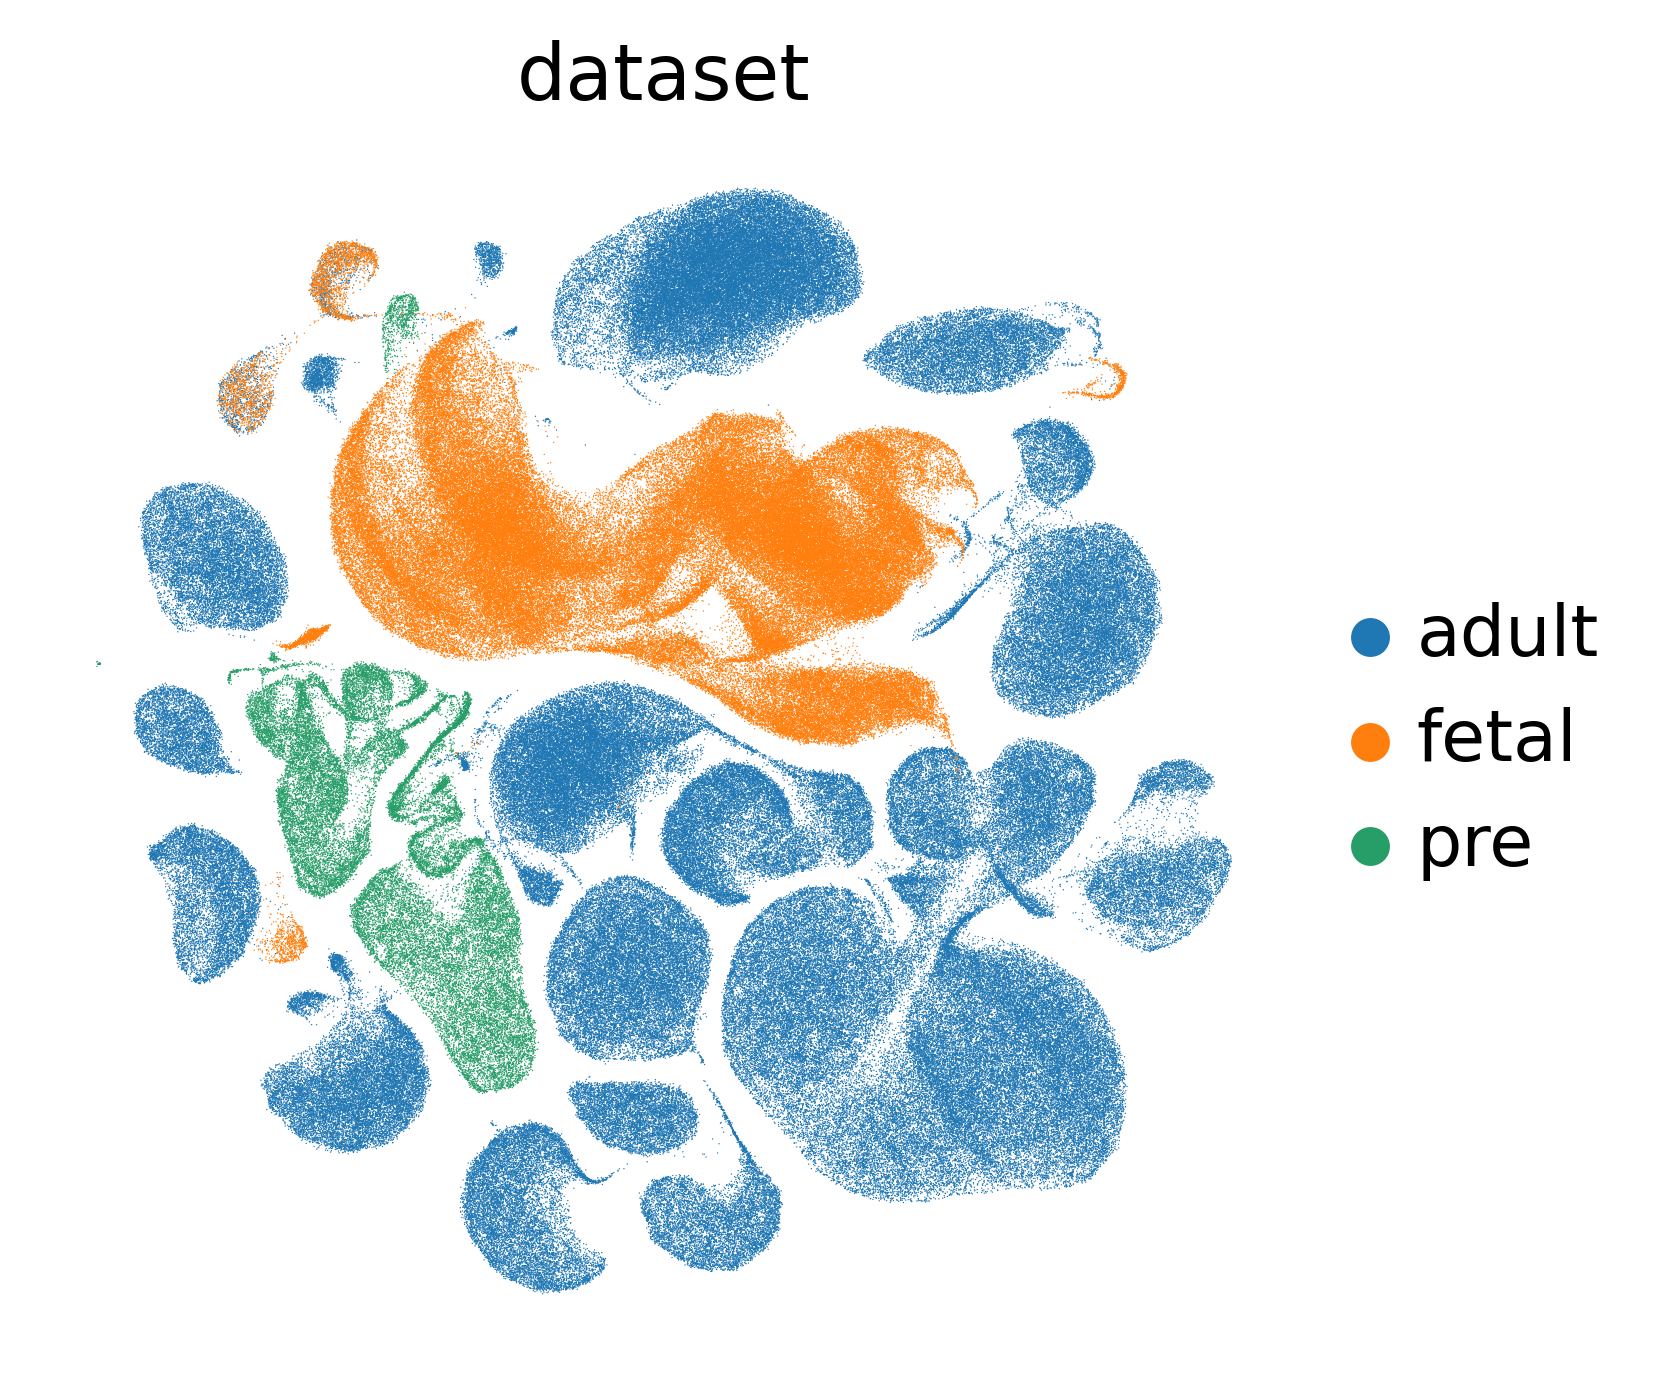

In [23]:
plt.figure()
sc.pl.umap(combined_adata, color="dataset",  frameon=False, show=True, save="pre_adult_reference_model_dataset_v2.pdf")

In [24]:
adata_hvg.write_h5ad('/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251021_fetal_adult_brain_merge_rename_scdevelopment/output/combined_scpoli_integrated.h5ad')

In [ ]:
adata_combined = sc.read_h5ad('/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251015_data_re_ref_10x_newversion_dnbctools/output/combined_samples.h5ad')

In [58]:
adata_combined

AnnData object with n_obs × n_vars = 15711 × 33456
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'sample_colors'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'distances', 'connectivities'

In [69]:
target_adata

AnnData object with n_obs × n_vars = 15711 × 2000
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'reanno'
    var: 'features'
    layers: 'counts'

In [70]:
counts_matrix = adata_combined.layers["counts"].toarray()
adata3 = sc.AnnData(X=counts_matrix, obs=adata_combined.obs.copy(), var=adata_combined.var.copy(), layers={'counts': counts_matrix})
adata3 = remove_sparsity(adata3)
all_genes = adata_hvg.var_names
missing_genes = all_genes.difference(adata3.var_names)
missing_data = np.zeros((adata3.shape[0], len(missing_genes)))
adata3_df = pd.DataFrame(adata3.X, columns=adata3.var_names, index=adata3.obs_names)
missing_df = pd.DataFrame(missing_data, columns=missing_genes, index=adata3.obs_names)
adata3_combined_df = pd.concat([adata3_df, missing_df], axis=1)
adata3_combined_df = adata3_combined_df[all_genes]
adata3_extended = sc.AnnData(
    X=adata3_combined_df.values, 
    obs=adata3.obs,
    var=pd.DataFrame(index=all_genes),
    layers={'counts': adata3_combined_df.values})
adata3_extended.var['features'] = adata_combined.var.reindex(all_genes).index
target_adata = adata3_extended.copy()
target_adata.obs['reanno'] = 'Unknown'
target_adata.obs['dataset'] = target_adata.obs['sample']
scpoli_query = scPoli.load_query_data(
    adata=target_adata,
    reference_model=scpoli_model,
    labeled_indices=[],
)
scpoli_query.train(
    n_epochs=50,
    pretraining_epochs=40,
    eta=5
)
print(target_adata.X.dtype)  # This is likely the x tensor
target_adata.X = target_adata.X.astype(np.float32)
print(target_adata.obs.dtypes)  # Check types in the annotations/metadata
print(target_adata.var.dtypes)  # Check types in the variable features (genes)
#Label transfer from reference to query
results_dict = scpoli_query.classify(target_adata, scale_uncertainties=True)
from sklearn.metrics import classification_report
# check the label transfer performance achieved
for i in range(len("reanno")):
    preds = results_dict["reanno"]["preds"]
    results_dict["reanno"]["uncert"]
    classification_df = pd.DataFrame(
        classification_report(
            y_true=target_adata.obs["reanno"],
            y_pred=preds,
            output_dict=True,
        )
    ).transpose()
print(classification_df)


Embedding dictionary:
 	Num conditions: [6]
 	Embedding dim: [5]
Encoder Architecture:
	Input Layer in, out and cond: 2000 45 5
	Mean/Var Layer in/out: 45 10
Decoder Architecture:
	First Layer in, out and cond:  10 45 5
	Output Layer in/out:  45 2000 



INFO:scarches.trainers.scpoli.trainer:GPU available: False


The missing labels are: {'Unknown'}
Therefore integer value of those labels is set to -1
The missing labels are: {'Unknown'}
Therefore integer value of those labels is set to -1
The missing labels are: {'Unknown'}
Therefore integer value of those labels is set to -1
The missing labels are: {'Unknown'}
Therefore integer value of those labels is set to -1
Initializing dataloaders
Starting training
 |████████████████----| 80.0%  - val_loss: 1323.37 - val_cvae_loss: 1323.37
Initializing unlabeled prototypes with Leiden with an unknown number of  clusters.
Clustering succesful. Found 25 clusters.
 |████████████████████| 100.0%  - val_loss: 1316.66 - val_cvae_loss: 1316.66 - val_prototype_loss:    0.00 - val_unlabeled_loss:    0.12
float64
sample                         category
n_genes_by_counts                 int32
log1p_n_genes_by_counts         float64
total_counts                    float32
log1p_total_counts              float32
pct_counts_in_top_50_genes      float64
pct_counts_in_to

<Axes: title={'center': 'reanno_pred'}, xlabel='UMAP1', ylabel='UMAP2'>

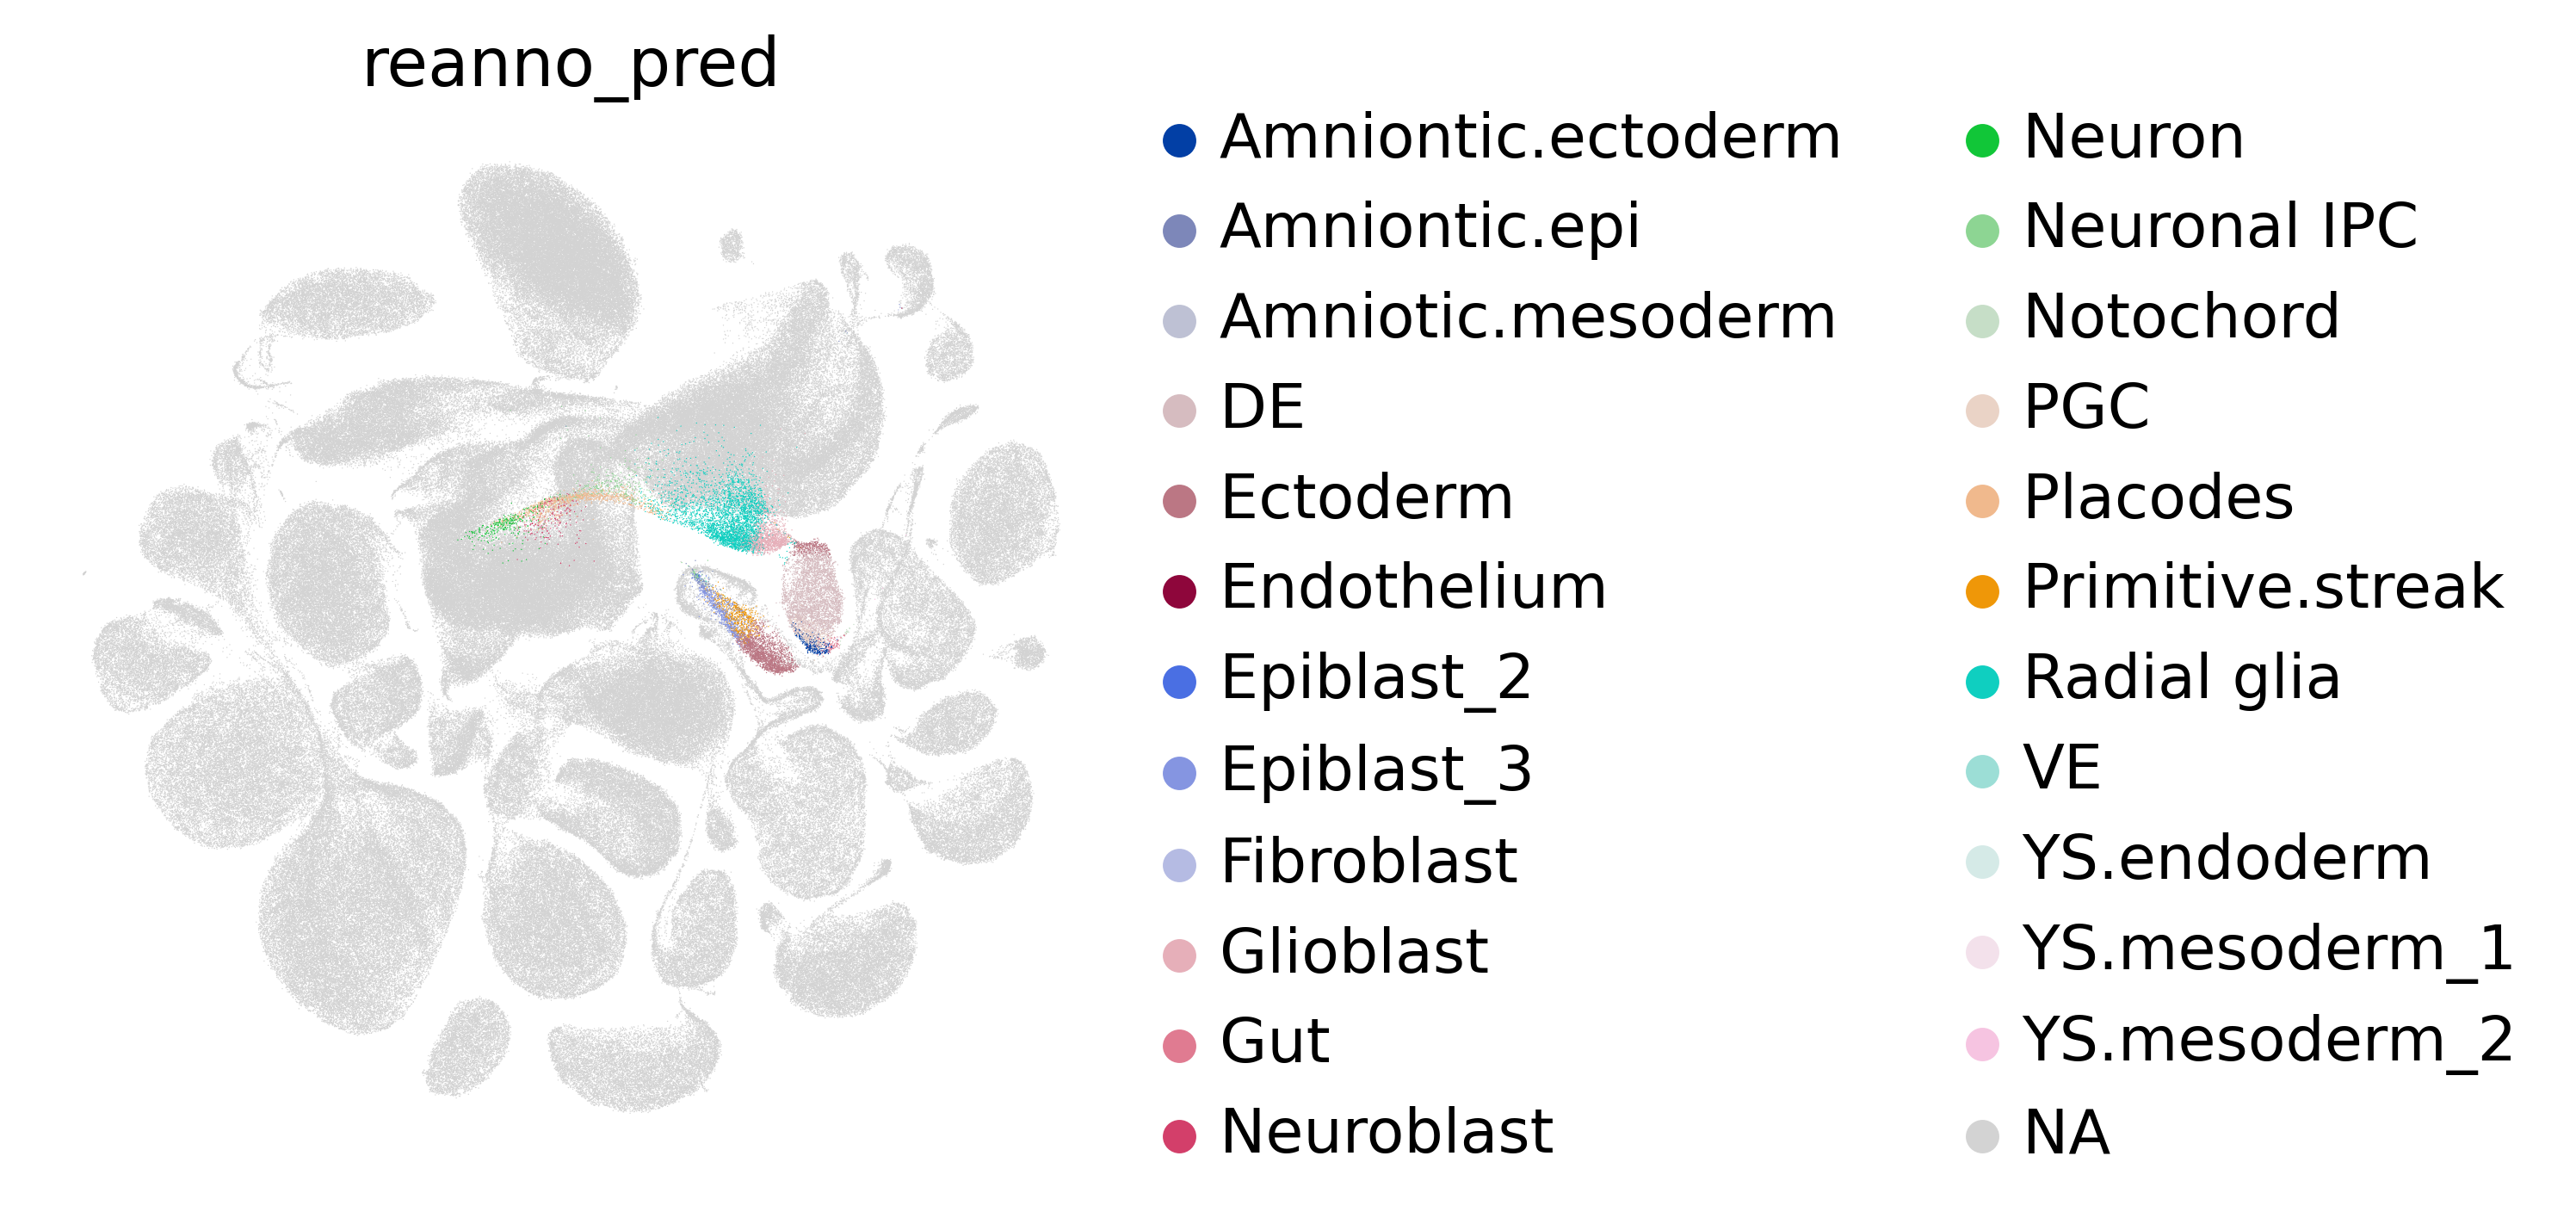

In [71]:
#get latent representation of reference data
scpoli_query.model.eval()
data_latent_source = scpoli_query.get_latent(
    adata_hvg,
    mean=True
)

adata_latent_source = sc.AnnData(data_latent_source)
adata_latent_source.obs = adata_hvg.obs.copy()

#get latent representation of query data
data_latent= scpoli_query.get_latent(
    target_adata,
    mean=True
)

adata_latent = sc.AnnData(data_latent)
adata_latent.obs = target_adata.obs.copy()

#get label annotations
adata_latent.obs['reanno_pred'] = results_dict['reanno']['preds'].tolist()
adata_latent.obs['reanno_uncert'] = results_dict['reanno']['uncert'].tolist()
adata_latent.obs['classifier_outcome'] = (
    adata_latent.obs['reanno_pred'] == adata_latent.obs['reanno']
)

#get prototypes
labeled_prototypes = scpoli_query.get_prototypes_info()
labeled_prototypes.obs['study'] = 'labeled prototype'
unlabeled_prototypes = scpoli_query.get_prototypes_info(prototype_set='unlabeled')
unlabeled_prototypes.obs['study'] = 'unlabeled prototype'

#join adatas
adata_latent_full = adata_latent_source.concatenate(
    [adata_latent, labeled_prototypes, unlabeled_prototypes],
    batch_key='query'
)
adata_latent_full.obs['reanno_pred'][adata_latent_full.obs['query'].isin(['0'])] = np.nan
sc.pp.neighbors(adata_latent_full, n_neighbors=15)
sc.tl.umap(adata_latent_full)
adata_no_prototypes = adata_latent_full[adata_latent_full.obs['query'].isin(['0', '1'])]
sc.pl.umap(
    adata_no_prototypes,
    color='reanno_pred',
    show=False,
    frameon=False,
)

In [72]:
adata_latent

AnnData object with n_obs × n_vars = 15711 × 10
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'reanno', 'dataset', 'conditions_combined', 'reanno_pred', 'reanno_uncert', 'classifier_outcome'

In [73]:
sc.pp.neighbors(adata_latent)
sc.tl.leiden(adata_latent)
sc.tl.umap(adata_latent)

<Axes: title={'center': 'reanno_pred'}, xlabel='UMAP1', ylabel='UMAP2'>

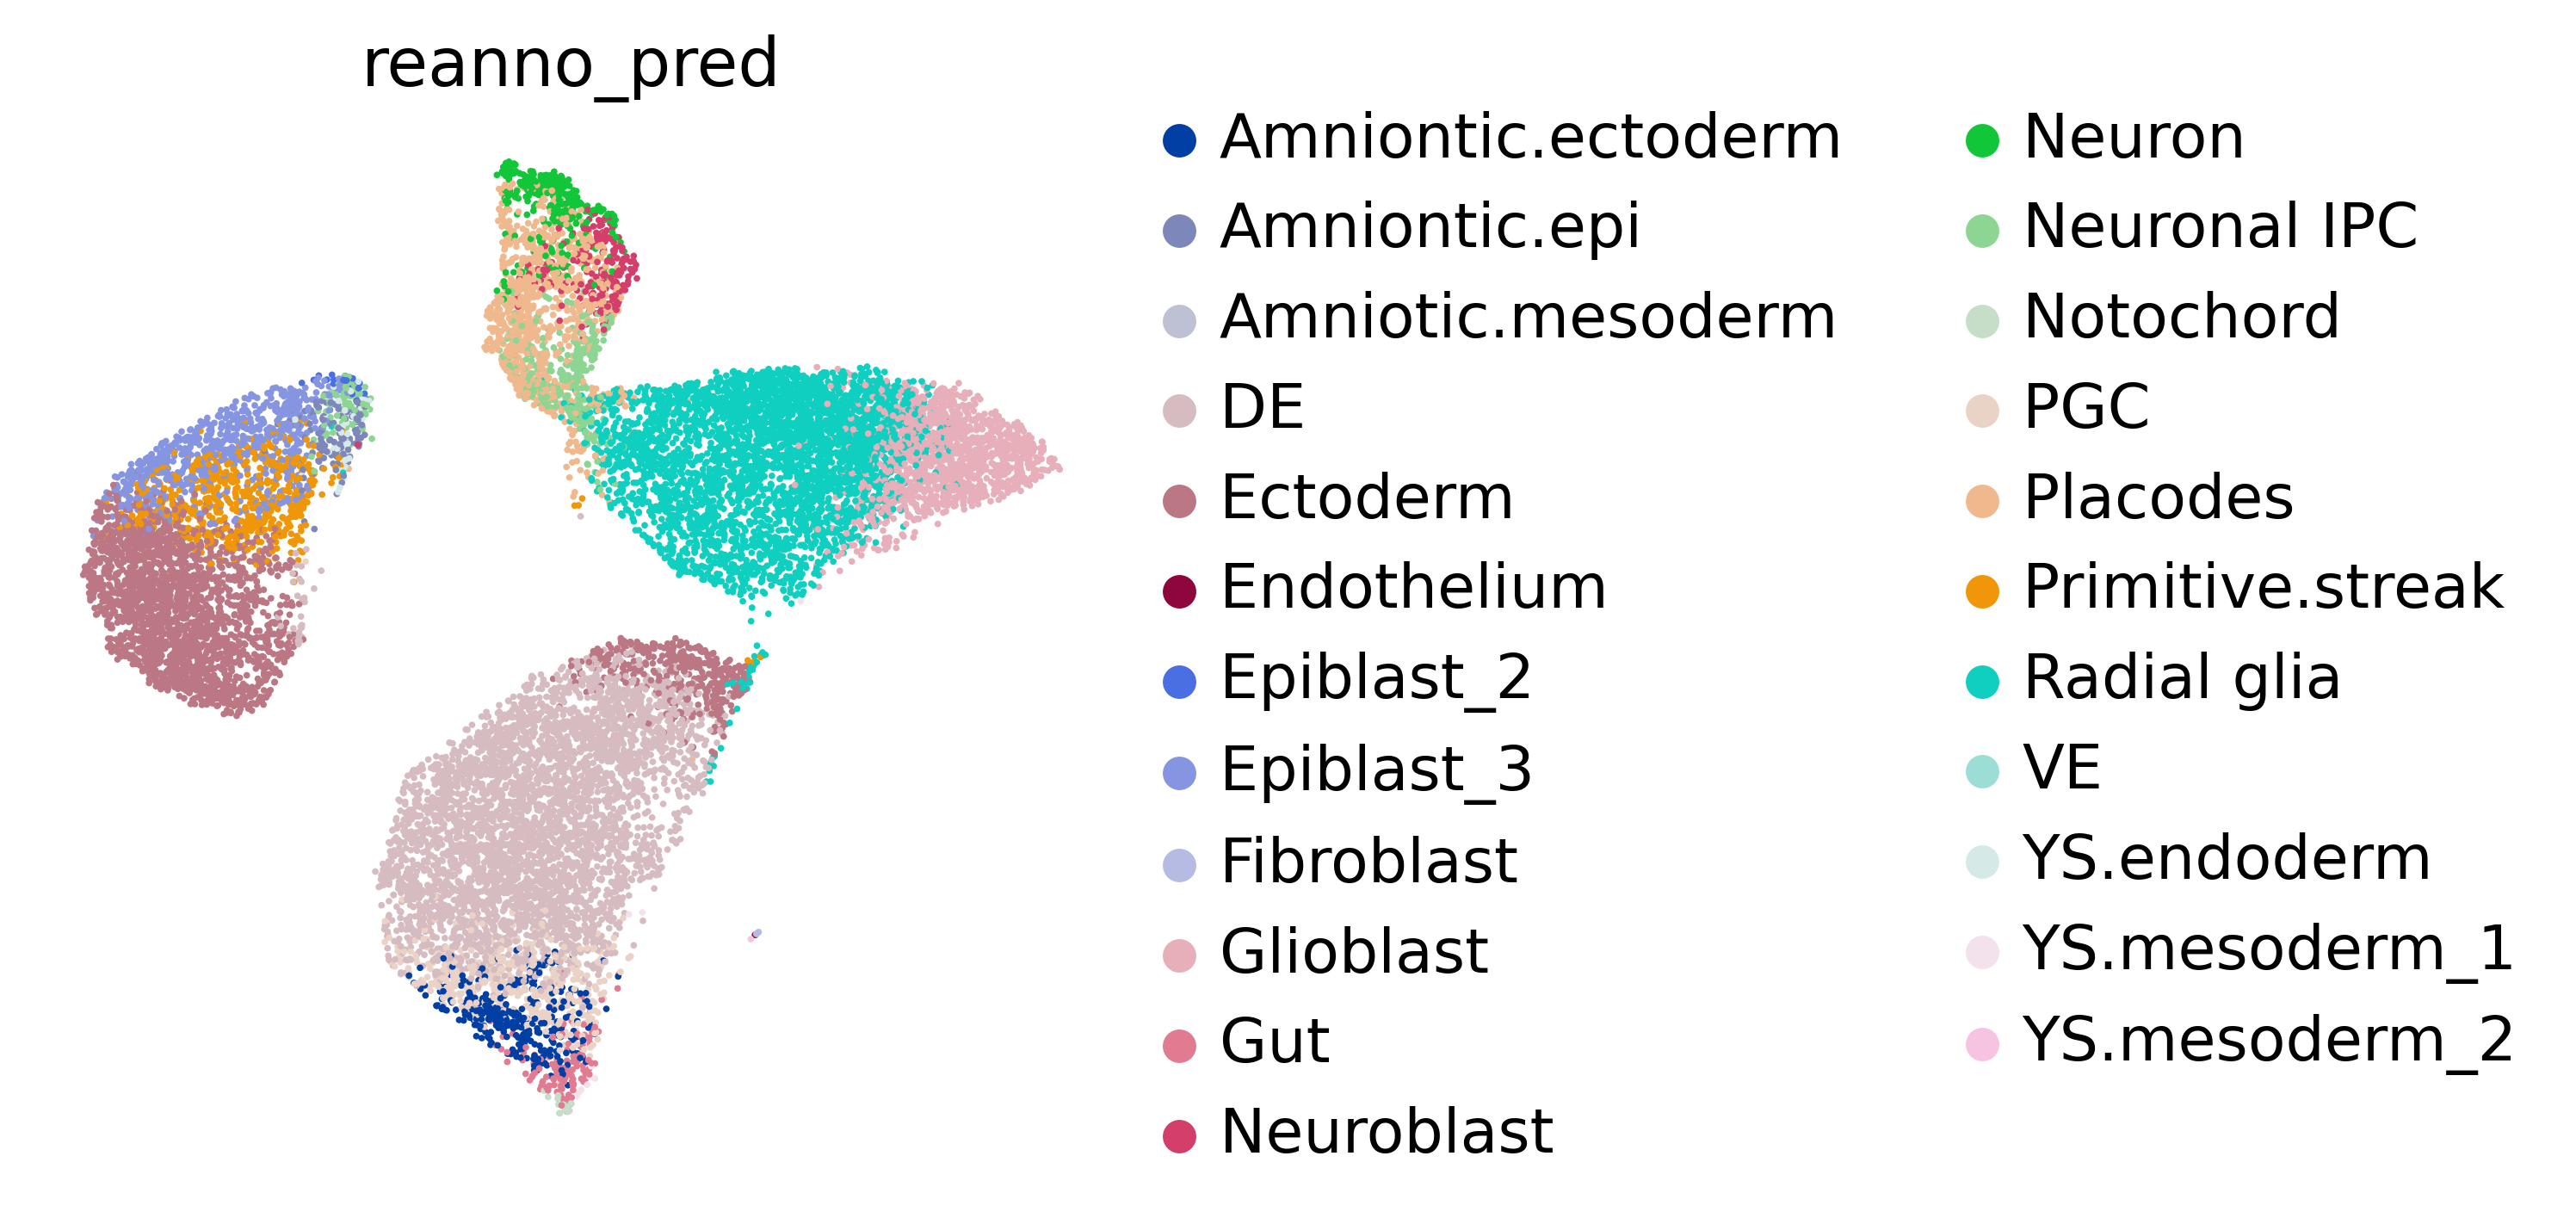

In [77]:
sc.pl.umap(
    adata_latent,
    color='reanno_pred',
    show=False,
    frameon=False,
)

In [ ]:

# === scVI整合 - 在高可变基因子集上计算 ===
print("\n=== scVI整合 ===")
print("准备counts层...")
from scipy import sparse
if sparse.issparse(adata_hvg.X):
    counts_data = np.expm1(adata_hvg.X.toarray())
else:
    counts_data = np.expm1(adata_hvg.X)
adata_hvg.layers["counts"] = sparse.csr_matrix(counts_data) if sparse.issparse(adata_hvg.X) else counts_data

# 设置scVI数据
scvi.model.SCVI.setup_anndata(adata_hvg, layer="counts", batch_key="dataset")

# 训练scVI模型
print("训练scVI模型...")
vae = scvi.model.SCVI(adata_hvg, gene_likelihood="nb", n_layers=2, n_latent=30)
vae.train()

# 获取潜在表示
adata_hvg.obsm["scVI"] = vae.get_latent_representation()

# === scANVI整合 - 在高可变基因子集上计算 ===
print("\n=== scANVI整合 ===")
print(f"Lineage类别: {adata_hvg.obs['lineage'].unique()}")

# 创建scANVI模型
lvae = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=adata_hvg,
    labels_key="lineage",
    unlabeled_category="Unknown",
)

# 训练scANVI
print("训练scANVI模型...")
lvae.train(max_epochs=50, n_samples_per_label=100)

# 获取scANVI潜在表示
adata_hvg.obsm["scANVI"] = lvae.get_latent_representation()

# 基于scANVI的聚类和UMAP - 在高可变基因子集上计算
print("基于scANVI的聚类...")
sc.pp.neighbors(adata_hvg, use_rep="scANVI", random_state=42)
sc.tl.leiden(adata_hvg, resolution=0.5, key_added="scANVI_res_0.5", random_state=42)
sc.tl.umap(adata_hvg, random_state=42)
adata_hvg.obsm['X_scANVI'] = adata_hvg.obsm['X_umap']

# === 将所有整合结果映射回原始数据 ===
print("\n=== 将所有整合结果映射回原始数据 ===")
integration_results = {
    'obsm': ['scVI', 'scANVI', 'X_scANVI'],
    'obs': ['scANVI_res_0.5']
}

# 映射obsm结果
for key in integration_results['obsm']:
    if key in adata_hvg.obsm:
        adata.obsm[key] = adata_hvg.obsm[key]
        print(f"✓ 映射 {key} 到原始数据")

# 映射obs结果
for key in integration_results['obs']:
    if key in adata_hvg.obs:
        adata.obs[key] = adata_hvg.obs[key]
        print(f"✓ 映射 {key} 到原始数据")

# === 使用原始数据（包含所有基因）进行可视化 ===
print("\n=== 使用原始数据进行可视化 ===")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 第一行：数据集分布
sc.pl.umap(adata, color=['dataset'], ax=axes[0,0], show=False, title='Dataset - scANVI')
sc.pl.umap(adata, color=['lineage'], ax=axes[0,1], show=False, title='Lineage - scANVI')
sc.pl.umap(adata, color=['reanno'], ax=axes[0,2], show=False, title='Cell Type - scANVI')

# 第二行：其他重要注释
if 'stage' in adata.obs.columns:
    sc.pl.umap(adata, color=['stage'], ax=axes[1,0], show=False, title='Stage - scANVI')
if 'orig_anno' in adata.obs.columns:
    sc.pl.umap(adata, color=['orig_anno'], ax=axes[1,1], show=False, title='Region - scANVI')
sc.pl.umap(adata, color=['scANVI_res_0.5'], ax=axes[1,2], show=False, title='Leiden Clusters - scANVI')

plt.tight_layout()
plt.savefig('/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251021_fetal_adult_brain_merge_rename_scdevelopment/output/scanvi_integrated_umap.png', dpi=300, bbox_inches='tight')
plt.show()

# === 验证映射结果 ===
print("\n=== 验证映射结果 ===")
print(f"原始数据基因数: {adata.n_vars}")
print(f"高可变基因子集基因数: {adata_hvg.n_vars}")
print("映射的降维结果:")
for key in ['scVI', 'scANVI', 'X_scANVI']:
    if key in adata.obsm:
        print(f"  ✓ {key}: {adata.obsm[key].shape}")

# 保存数据
print("\n保存数据...")
adata.write_h5ad('/storage2/liuxiaodongLab/jiangjing/Projects/XueyingFan/PD_XueyingFan/20251021_fetal_adult_brain_merge_rename_scdevelopment/output/combined_integrated.h5ad')

print("\n整合完成!")
print(f"最终原始数据: {adata.n_obs} 细胞, {adata.n_vars} 基因 (包含所有基因)")
print(f"可用于下游分析如: 差异表达分析、基因表达可视化等")